In [1]:
#!pip install planetaryimage spectral rasterio matplotlib numpy
#!pip install pds4_tools

#!pip install pvl rasterio numpy matplotlib

In [1]:
import pvl
import numpy as np

# Load label
label = pvl.load("C:/Users/PhD24-2/Downloads/M3d1d2/M3D1_V01_L2.LBL")

# Extract image file name
print(label.keys())



KeysView(['PDS_VERSION_ID', 'LABEL_REVISION_NOTE', 'DATA_SET_ID', 'PRODUCT_ID', 'RECORD_TYPE', 'MISSION_ID', 'MISSION_NAME', 'INSTRUMENT_HOST_ID', 'INSTRUMENT_HOST_NAME', 'INSTRUMENT_NAME', 'INSTRUMENT_ID', 'TARGET_NAME', 'TARGET_TYPE', 'MISSION_PHASE_NAME', 'PRODUCT_TYPE', 'PRODUCT_CREATION_TIME', 'START_TIME', 'STOP_TIME', 'SPACECRAFT_CLOCK_START_COUNT', 'SPACECRAFT_CLOCK_STOP_COUNT', 'ORBIT_NUMBER', 'PRODUCT_VERSION_TYPE', 'PRODUCER_INSTITUTION_NAME', 'SOFTWARE_NAME', 'SOFTWARE_VERSION_ID', 'DESCRIPTION', 'SOLAR_DISTANCE', 'INSTRUMENT_MODE_ID', 'DETECTOR_TEMPERATURE', 'CH1:SWATH_WIDTH', 'CH1:SWATH_LENGTH', 'CH1:SPACECRAFT_YAW_DIRECTION', 'CH1:ORBIT_LIMB_DIRECTION', 'SPACECRAFT_ORIENTATION', 'CH1:INITIAL_SC_ORIENTATION', 'CH1:SC_ORIENTATION_EPOCH_TDB_TIME', 'CH1:SC_ORIENTATION_RATE', 'CH1:SC_ROTATION_AXIS_VECTOR', 'CH1:SC_ROTATION_RATE', '^DESCRIPTION', 'CH1:SPECTRAL_CALIBRATION_FILE_NAME', 'CH1:RAD_GAIN_FACTOR_FILE_NAME', 'CH1:GLOBAL_BANDPASS_FILE_NAME', 'SOURCE_DATA_SET_ID', 'SOURC

In [2]:
from spectral.io import envi

hdr = r"C:/Users/PhD24-2/Downloads//M3d1d2/M3D1_V01_RFL.HDR"
img_file = r"C:/Users/PhD24-2/Downloads//M3d1d2/M3D1_V01_RFL.IMG"

img = envi.open(hdr, img_file)

data = img.load()

print(data.shape)

C:\Users\PhD24-2\anaconda3\Lib\site-packages\spectral\io\envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


(28770, 304, 85)


In [3]:
print(img)
print(data.shape)

	Data Source:   'C:/Users/PhD24-2/Downloads//M3d1d2/M3D1_V01_RFL.IMG'
	# Rows:          28770
	# Samples:         304
	# Bands:            85
	Interleave:        BIL
	Quantization:  32 bits
	Data format:   float32
(28770, 304, 85)


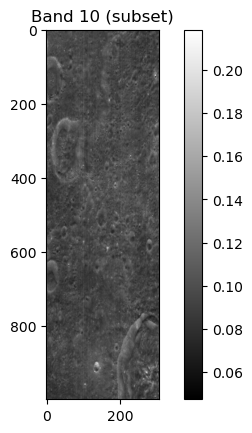

In [4]:
import matplotlib.pyplot as plt

subset = data[0:1000, :, 10]  # first 1000 rows, band 10

plt.imshow(subset, cmap='gray')
plt.colorbar()
plt.title("Band 10 (subset)")
plt.show()

In [6]:
data = np.array(data)

(1000, 304, 3)


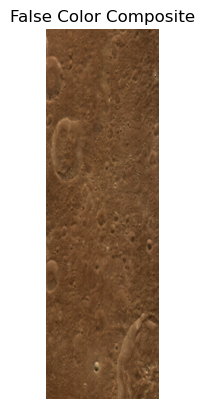

In [7]:
import numpy as np
import matplotlib.pyplot as plt

subset = data[0:1000, :, :]

rgb = np.dstack((
    subset[:, :, 60],
    subset[:, :, 40],
    subset[:, :, 20]
))

# Normalize safely
rgb_min = np.nanmin(rgb)
rgb_max = np.nanmax(rgb)

rgb = (rgb - rgb_min) / (rgb_max - rgb_min)
print(rgb.shape)
plt.imshow(rgb)
plt.title("False Color Composite")
plt.axis('off')
plt.show()

In [8]:
print(img.metadata)

{'samples': '304', 'lines': '28770', 'bands': '85', 'major frame offsets': ['0', '0'], 'file type': 'ENVI Standard', 'data type': '4', 'interleave': 'bil', 'byte order': '0', 'flip': '4', 'temperature': '166.33', 'beta angle': '2.83', 'dark signal image': 'M3G20090620T134022_V01_L0.IMG', 'bad detector element map': 'M3G20090620T134022_V01_BDE.IMG', 'flat field image': 'M3G20090620T134543_V01_FF.IMG', 'data ignore value': '-999.0', 'description': 'Cumulative Processing Steps follow:\n-----------------------------------------------\nM3 Global Mode Calibrated Data version u2;\nRaw image;\nDark signal subtraction;\nBad detector element interpolation;\nInterpolate filter edges c13,c50;\nInterpolate detector panel edges s81,s161,s241;\nElectronic panel ghost correction;\nDark pedestal shift correction;\nScattered light correction;\nLaboratory flat field;\nImage based flat field w/ photometry preserved;\nApply radiometric calibration coefficients;\nUnits (W/m^2/um/sr);\nStarting from L1B abov

In [9]:
pixel = data[500, 150, :]
print(pixel)

[-9.99000000e+02 -9.99000000e+02  6.27004132e-02  6.73983693e-02
  7.11464509e-02  7.65571520e-02  7.87398592e-02  8.32088143e-02
  8.46071988e-02  8.66495445e-02  9.03201774e-02  9.05636847e-02
  9.07930210e-02  9.00831148e-02  9.23544839e-02  9.68364105e-02
  9.73335207e-02  1.00398093e-01  1.02795005e-01  1.10247813e-01
  1.08553670e-01  1.06993638e-01  1.11246824e-01  1.13600560e-01
  1.15580559e-01  1.15345731e-01  1.18812896e-01  1.22622341e-01
  1.23813830e-01  1.26141503e-01  1.26331374e-01  1.29664660e-01
  1.31409422e-01  1.31838873e-01  1.34448886e-01  1.35965824e-01
  1.36884406e-01  1.37556598e-01  1.39156282e-01  1.40025377e-01
  1.43448547e-01  1.44741803e-01  1.45907640e-01  1.49240747e-01
  1.47909850e-01  1.49103016e-01  1.52507022e-01  1.52956530e-01
  1.54675245e-01  1.56966761e-01  1.58355206e-01  1.62112549e-01
  1.63415581e-01  1.68120176e-01  1.69846281e-01  1.72797680e-01
  1.76786438e-01  1.78134248e-01  1.74962953e-01  1.83874741e-01
  1.87036172e-01  1.90888

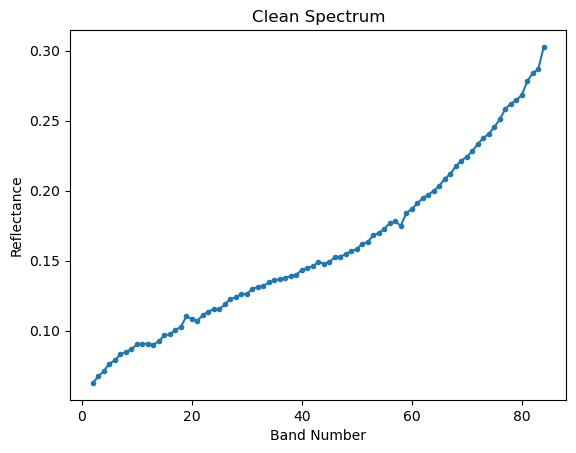

In [10]:
import numpy as np
import matplotlib.pyplot as plt

pixel = data[500, 150, :]

# Mask invalid values
pixel_clean = np.where(pixel < -900, np.nan, pixel)

plt.plot(pixel_clean, marker='.')
plt.xlabel("Band Number")
plt.ylabel("Reflectance")
plt.title("Clean Spectrum")
plt.show()

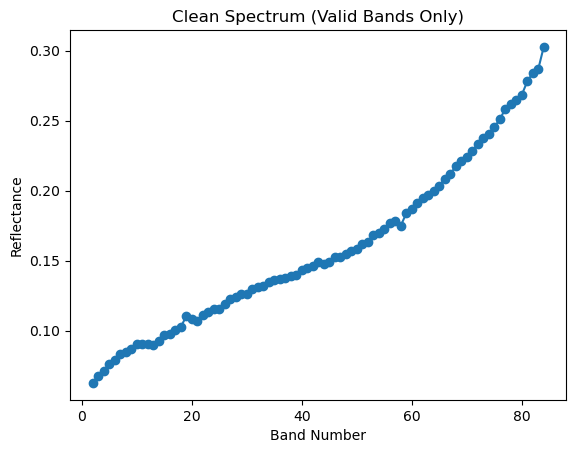

In [11]:
valid = pixel > -900

plt.plot(np.arange(len(pixel))[valid], pixel[valid], marker='o')
plt.xlabel("Band Number")
plt.ylabel("Reflectance")
plt.title("Clean Spectrum (Valid Bands Only)")
plt.show()

In [12]:
print(img.metadata.get('wavelength'))

['460.9900', '500.9200', '540.8400', '580.7600', '620.6900', '660.6100', '700.5400', '730.4800', '750.4400', '770.4000', '790.3700', '810.3300', '830.2900', '850.2500', '870.2100', '890.1700', '910.1400', '930.1000', '950.0600', '970.0200', '989.9800', '1009.950', '1029.910', '1049.870', '1069.830', '1089.790', '1109.760', '1129.720', '1149.680', '1169.640', '1189.600', '1209.570', '1229.530', '1249.490', '1269.450', '1289.410', '1309.380', '1329.340', '1349.300', '1369.260', '1389.220', '1409.190', '1429.150', '1449.110', '1469.070', '1489.030', '1508.990', '1528.960', '1548.920', '1578.860', '1618.790', '1658.710', '1698.630', '1738.560', '1778.480', '1818.400', '1858.330', '1898.250', '1938.180', '1978.100', '2018.020', '2057.950', '2097.870', '2137.800', '2177.720', '2217.640', '2257.570', '2297.490', '2337.420', '2377.340', '2417.260', '2457.190', '2497.110', '2537.030', '2576.960', '2616.880', '2656.810', '2696.730', '2736.650', '2776.580', '2816.500', '2856.430', '2896.350', '29

In [13]:
wavelengths = np.array(img.metadata.get('wavelength'), dtype=float)  # convert to µm
#print(wavelengths)
wv = wavelengths/1000 
print(wv[:5])

[0.46099 0.50092 0.54084 0.58076 0.62069]


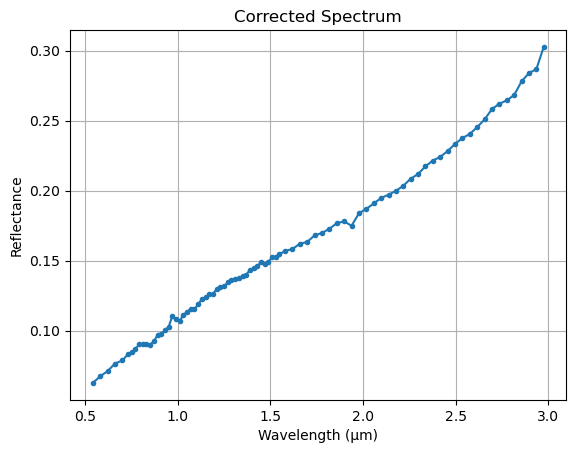

In [14]:
pixel = data[500, 150, :]

valid = pixel > -900

import matplotlib.pyplot as plt

plt.plot(wv[valid], pixel[valid], marker='.')
plt.xlabel("Wavelength (µm)")
plt.ylabel("Reflectance")
plt.title("Corrected Spectrum")
plt.grid()
plt.show()

In [29]:
from spectral.io import envi

hdr = r"C:/Users/PhD24-2/Downloads/M3d1d2/M3D1_V01_LOC.HDR"
img_file = r"C:/Users/PhD24-2/Downloads/M3d1d2/M3D1_V01_LOC.IMG"

loc = envi.open(hdr, img_file)
loc_data = np.array(loc.load())

print(loc_data.shape)

print(loc.metadata)

(28770, 304, 3)
{'description': 'M3 Level 1B Pixel Center Locations, MOON_ME frame, decimal degrees and\nmeters [Mon Nov 08 14:39:24 2010]', 'samples': '304', 'lines': '28770', 'bands': '3', 'header offset': '0', 'file type': 'ENVI Standard', 'data type': '5', 'interleave': 'bil', 'sensor type': 'Unknown', 'byte order': '0', 'wavelength units': 'Unknown', 'band names': ['Longitude', 'Latitude', 'Radius']}


In [9]:
lon = loc_data[:, :, 0]
lat = loc_data[:, :, 1]
lon = np.where(lon > 180, lon - 360, lon)

print(np.nanmin(lat), np.nanmax(lat))
print(np.nanmin(lon), np.nanmax(lon))

-84.20518 57.29629
-162.70271 -137.03847


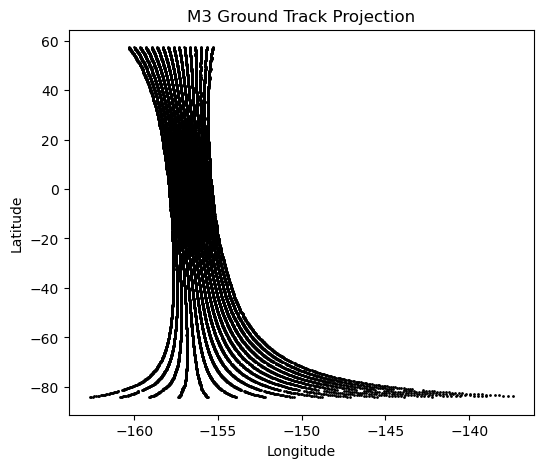

In [10]:
import matplotlib.pyplot as plt

# Downsample for speed
step = 20

plt.figure(figsize=(6,5))
plt.scatter(
    lon[::step, ::step],
    lat[::step, ::step],
    s=1,
    c='black'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("M3 Ground Track Projection")
plt.show()

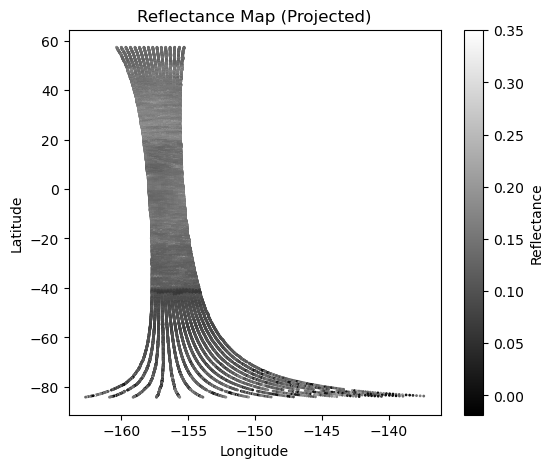

In [12]:
band = data[:, :, 30]  # pick a band

plt.figure(figsize=(6,5))
plt.scatter(
    lon[::step, ::step],
    lat[::step, ::step],
    c=band[::step, ::step],
    s=1,
    cmap='gray'
)

plt.colorbar(label="Reflectance")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Reflectance Map (Projected)")
plt.show()

In [21]:
lon_min, lon_max = np.nanmin(lon), np.nanmax(lon)
lat_min, lat_max = np.nanmin(lat), np.nanmax(lat)

print(lon_min, lon_max)
print(lat_min, lat_max)

-162.70271 -137.03847
-84.20518 57.29629


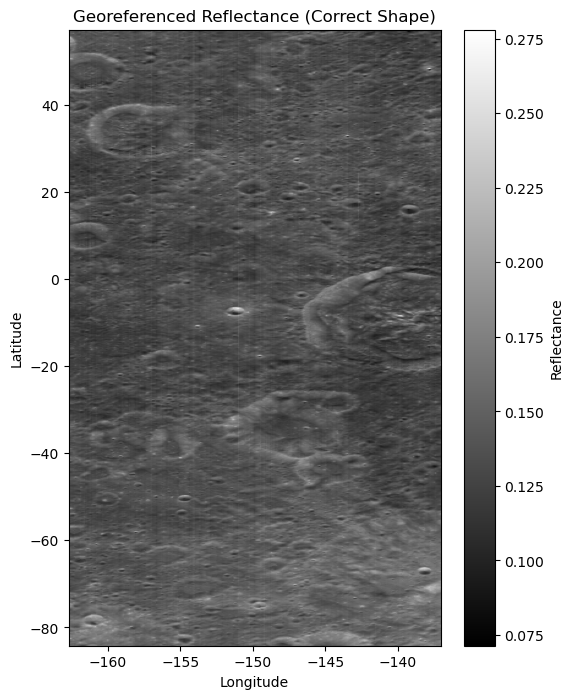

In [22]:
plt.figure(figsize=(6,8))

subset = band[0:2000, :]  # same subset

plt.imshow(
    subset,
    cmap='gray',
    aspect='auto',
    extent=[lon_min, lon_max, lat_min, lat_max]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Georeferenced Reflectance (Correct Shape)")
plt.colorbar(label="Reflectance")

plt.show()

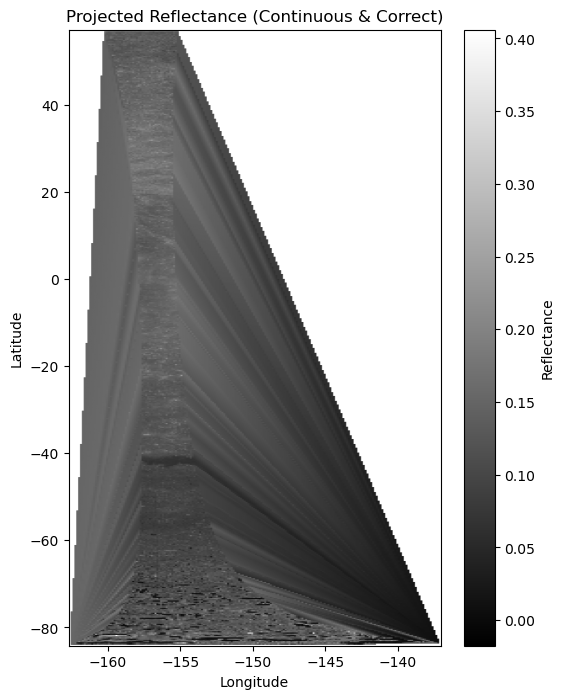

In [27]:
import numpy as np

# Define grid resolution (you can tweak)
lat_grid = np.linspace(np.nanmin(lat), np.nanmax(lat), 500)
lon_grid = np.linspace(np.nanmin(lon), np.nanmax(lon), 200)

lon_grid_2d, lat_grid_2d = np.meshgrid(lon_grid, lat_grid)

from scipy.interpolate import griddata

# Flatten original data
points = np.column_stack((lon.flatten(), lat.flatten()))
values = band.flatten()

# Remove invalid values
mask = (
    (values > -900) &
    (~np.isnan(points[:,0])) &
    (~np.isnan(points[:,1]))
)

points = points[mask]
values = values[mask]

# Interpolate
grid = griddata(
    points,
    values,
    (lon_grid_2d, lat_grid_2d),
    method='linear'
)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,8))

plt.imshow(
    grid,
    extent=[lon_grid.min(), lon_grid.max(), lat_grid.min(), lat_grid.max()],
    origin='lower',
    cmap='gray',
    aspect='auto'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Projected Reflectance (Continuous & Correct)")
plt.colorbar(label="Reflectance")

plt.show()

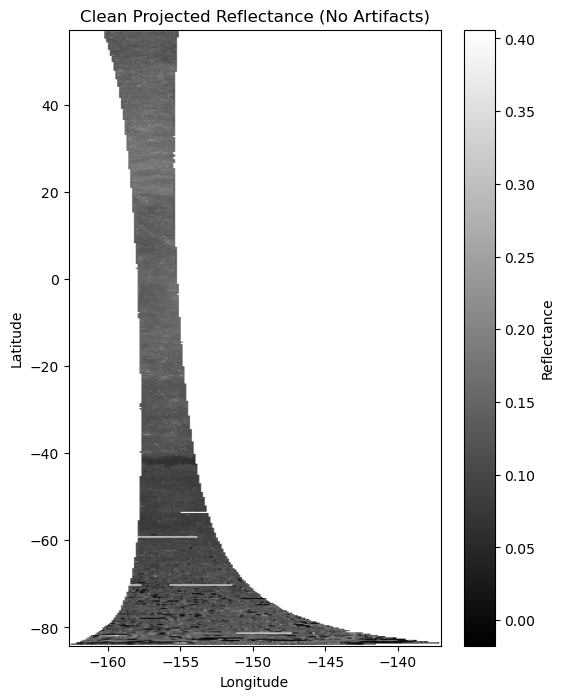

In [28]:
from scipy.spatial import cKDTree

# Build tree from real data points
tree = cKDTree(points)

# Query distance to nearest real pixel
dist, _ = tree.query(
    np.column_stack((lon_grid_2d.ravel(), lat_grid_2d.ravel())),
    k=1
)

dist = dist.reshape(lon_grid_2d.shape)

threshold = 0.1  # tweak this if needed

grid_masked = np.where(dist < threshold, grid, np.nan)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,8))

plt.imshow(
    grid_masked,
    extent=[lon_grid.min(), lon_grid.max(), lat_grid.min(), lat_grid.max()],
    origin='lower',
    cmap='gray',
    aspect='auto'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Clean Projected Reflectance (No Artifacts)")
plt.colorbar(label="Reflectance")

plt.show()

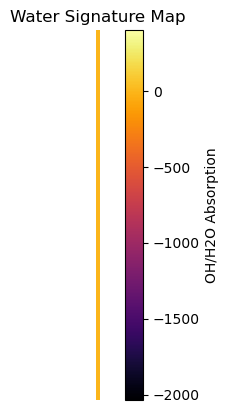

In [15]:
def find_band(target):
    return np.argmin(np.abs(wv - target))

b1 = find_band(2.6)
b2 = find_band(2.8)
b3 = find_band(3.0)

R1 = data[:, :, b1]
R2 = data[:, :, b2]
R3 = data[:, :, b3]

continuum = (R1 + R3) / 2
band_depth = (continuum - R2) / continuum

bd_small = band_depth[::10, ::10]

plt.imshow(bd_small, cmap='inferno')
plt.colorbar(label="OH/H2O Absorption")
plt.title("Water Signature Map")
plt.axis('off')
plt.show()

In [18]:
data_np = np.array(data)

# Replace invalid values
data_np = np.where(data_np < -900, np.nan, data_np)

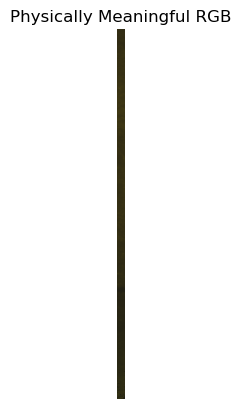

In [19]:
def find_band(target):
    return np.argmin(np.abs(wv - target))

# Visible-ish mapping
r = find_band(0.9)
g = find_band(0.7)
b = find_band(0.5)

rgb = np.dstack((data_np[:, :, r],
                 data_np[:, :, g],
                 data_np[:, :, b]))

rgb = np.nan_to_num(rgb)
rgb = (rgb - np.min(rgb)) / (np.max(rgb) - np.min(rgb))

rgb_small = rgb[::10, ::5, :]

plt.imshow(rgb_small)
plt.title("Physically Meaningful RGB")
plt.axis('off')
plt.show()

In [20]:
import numpy as np

data_np = np.array(data)
data_np = np.where(data_np < -900, np.nan, data_np)

for i in range(data_np.shape[2]):
    band = data_np[:, :, i]
    
    if np.all(np.isnan(band)):
        # If entire band is invalid → set to 0 (or skip later)
        data_np[:, :, i] = 0
    else:
        mean_val = np.nanmean(band)
        band = np.where(np.isnan(band), mean_val, band)
        data_np[:, :, i] = band

In [21]:
valid_bands = []

for i in range(data_np.shape[2]):
    band = data_np[:, :, i]
    if not np.all(np.isnan(band)):
        valid_bands.append(i)

print("Valid bands:", len(valid_bands))
data_clean = data_np[:, :, valid_bands]

Valid bands: 85


In [22]:
for i in range(data_clean.shape[2]):
    band = data_clean[:, :, i]
    mean_val = np.nanmean(band)
    band = np.where(np.isnan(band), mean_val, band)
    data_clean[:, :, i] = band

In [23]:
from sklearn.decomposition import PCA

h, w, b = data_clean.shape
X = data_clean.reshape(-1, b)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

img_pca = X_pca.reshape(h, w, 3)

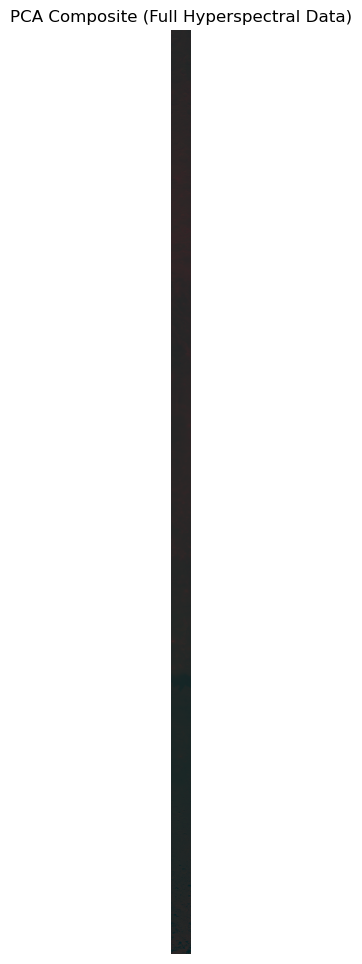

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Normalize for display
img_pca_norm = (img_pca - np.min(img_pca)) / (np.max(img_pca) - np.min(img_pca))

# Downsample (important because image is huge)
img_small = img_pca_norm[::10, ::5, :]

plt.figure(figsize=(6, 12))
plt.imshow(img_small)
plt.title("PCA Composite (Full Hyperspectral Data)")
plt.axis('off')
plt.show()

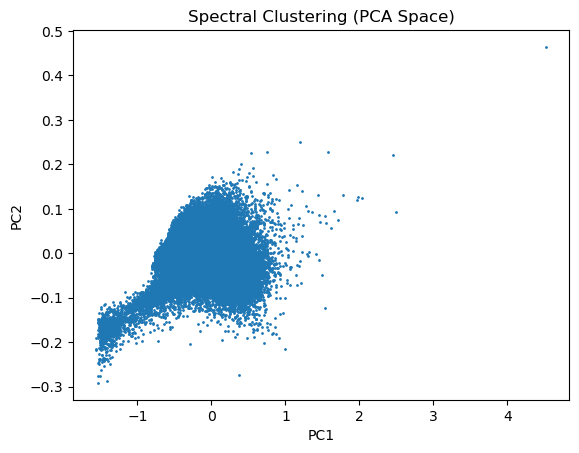

In [25]:
# Take subset (for speed)
X_sample = X[::100]

X_pca_sample = pca.transform(X_sample)

plt.scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], s=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Spectral Clustering (PCA Space)")
plt.show()

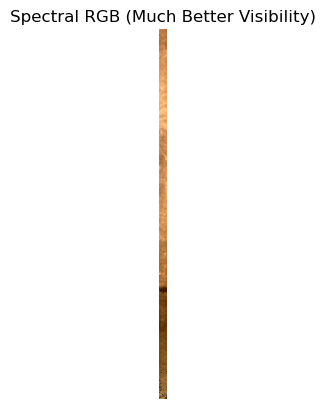

In [26]:
def find_band(target):
    return np.argmin(np.abs(wv - target))

r = find_band(2.2)
g = find_band(1.5)
b = find_band(1.0)

rgb = np.dstack((
    data[:, :, r],
    data[:, :, g],
    data[:, :, b]
))

rgb = np.where(rgb < -900, np.nan, rgb)

# Percentile stretch
p2, p98 = np.nanpercentile(rgb, (2, 98))
rgb = (rgb - p2) / (p98 - p2)
rgb = np.clip(rgb, 0, 1)

rgb_small = rgb[::10, ::5, :]

plt.imshow(rgb_small)
plt.title("Spectral RGB (Much Better Visibility)")
plt.axis('off')
plt.show()

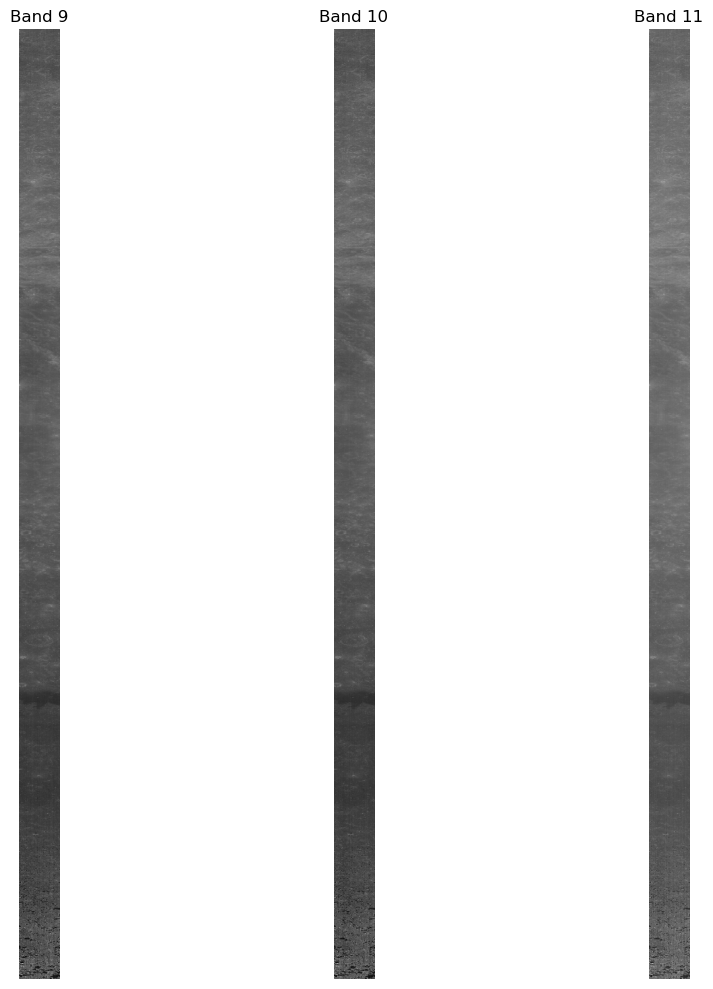

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Clean data (just in case)
data_np = np.where(data < -900, np.nan, data)

# Select bands
b9  = data_np[:, :, 8]
b10 = data_np[:, :, 9]
b11 = data_np[:, :, 10]

# Downsample for speed
b9_s  = b9[::20, ::5]
b10_s = b10[::20, ::5]
b11_s = b11[::20, ::5]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 10))

bands = [b9_s, b10_s, b11_s]
titles = ["Band 9", "Band 10", "Band 11"]

for i in range(3):
    im = axes[i].imshow(bands[i], cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [28]:
def stretch(img):
    p2, p98 = np.nanpercentile(img, (2, 98))
    img = (img - p2) / (p98 - p2)
    return np.clip(img, 0, 1)

b9_s  = stretch(b9_s)
b10_s = stretch(b10_s)
b11_s = stretch(b11_s)

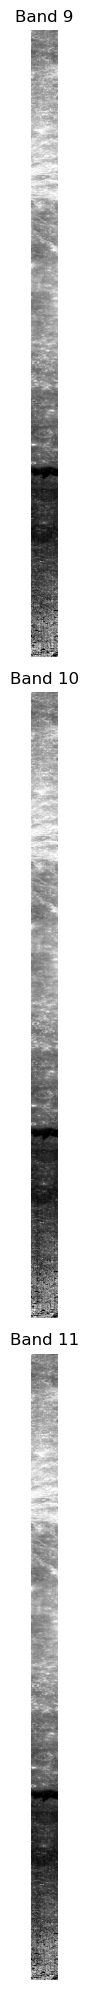

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(19, 20))

for i, band in enumerate([b9_s, b10_s, b11_s]):
    axes[i].imshow(band, cmap='gray')
    axes[i].set_title(f"Band {9+i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

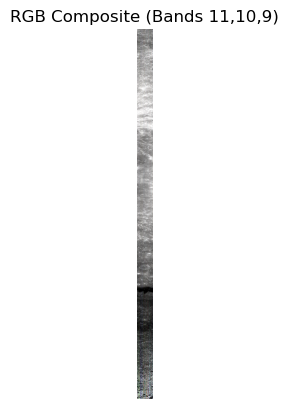

In [30]:
rgb = np.dstack((b11_s, b10_s, b9_s))  # R,G,B

plt.imshow(rgb)
plt.title("RGB Composite (Bands 11,10,9)")
plt.axis('off')
plt.show()

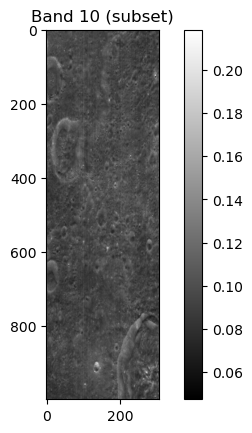

In [31]:
import matplotlib.pyplot as plt

subset = data[0:1000, :, 10]  # first 1000 rows, band 10

plt.imshow(subset, cmap='gray')
plt.colorbar()
plt.title("Band 10 (subset)")
plt.show()

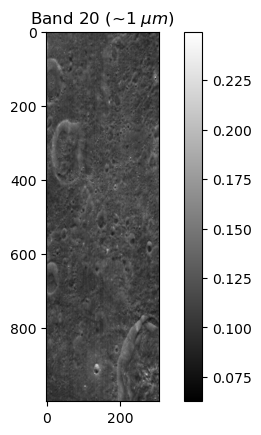

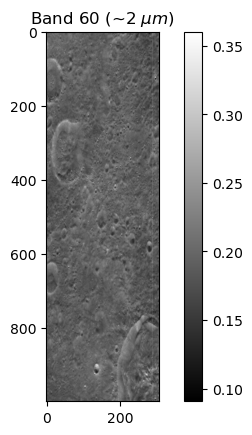

In [32]:
import matplotlib.pyplot as plt

subset = data[0:1000, :, 20]  # first 1000 rows, band 20 ~1 micrometer

plt.imshow(subset, cmap='gray')
plt.colorbar()
plt.title("Band 20 (~1 $\mu m$)")
plt.show()

subset = data[0:1000, :, 60]  # first 1000 rows, band 60 ~2 micrometer

plt.imshow(subset, cmap='gray')
plt.colorbar()
plt.title("Band 60 (~2 $\mu m$)")
plt.show()

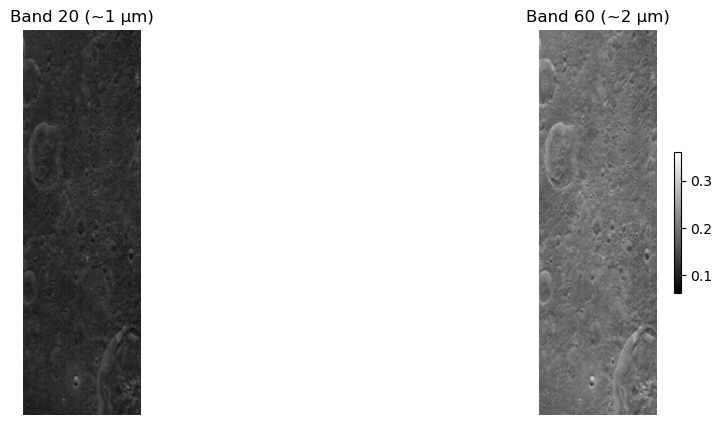

In [33]:
subset1 = data[0:1000, :, 20]
subset2 = data[0:1000, :, 60]

# Remove invalid values
subset1 = np.where(subset1 < -900, np.nan, subset1)
subset2 = np.where(subset2 < -900, np.nan, subset2)

# Use same limits
vmin = np.nanmin([subset1, subset2])
vmax = np.nanmax([subset1, subset2])

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(subset1, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("Band 20 (~1 µm)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(subset2, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("Band 60 (~2 µm)")
plt.axis('off')

plt.colorbar(fraction=0.02)
plt.show()

In [34]:
from spectral.io import envi
import numpy as np

hdr_sup = r"C:/Users/PhD24-2/Downloads//M3d1d2/M3D1_V01_SUP.HDR"
img_sup = r"C:/Users/PhD24-2/Downloads//M3d1d2/M3D1_V01_SUP.IMG"

sup = envi.open(hdr_sup, img_sup)
sup_data = np.array(sup.load())

print(sup_data.shape)

(28770, 304, 3)


In [35]:
for i in range(sup_data.shape[2]):
    band = sup_data[:, :, i]
    print(i, np.nanmin(band), np.nanmax(band))

0 -0.051627267 1.1245184
1 0.1 381.9782
2 -0.12450952 5.256426


In [39]:
lat_lin = np.linspace(-84, 57, band20.shape[0])
lon_lin = np.linspace(197, 222, band20.shape[1])

lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)

# Fix longitude
lon_grid = np.where(lon_grid > 180, lon_grid - 360, lon_grid)

In [40]:
band20 = data[:, :, 19]
band20 = np.where(band20 < -900, np.nan, band20)

band_s = band20[::20, ::5]
lat_s = lat_grid[::20, ::5]
lon_s = lon_grid[::20, ::5]

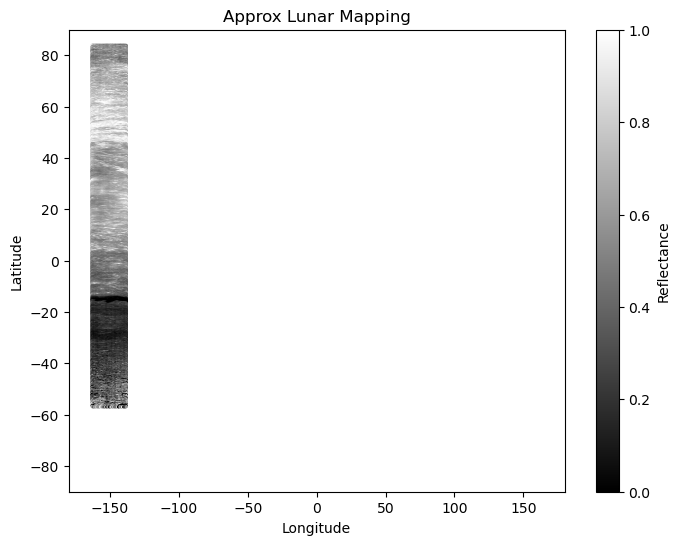

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Extract band correctly
band20 = data[:, :, 19]
band20 = np.where(band20 < -900, np.nan, band20)

# Downsample
band_s = band20[::20, ::5]
lat_s = lat_grid[::20, ::5]
lon_s = lon_grid[::20, ::5]
lat_s = -lat_s
lon_s = lon_s
# Contrast stretch
p2, p98 = np.nanpercentile(band_s, (2, 98))
band_s = (band_s - p2) / (p98 - p2)
band_s = np.clip(band_s, 0, 1)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(lon_s, lat_s, c=band_s, s=1, cmap='gray')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Approx Lunar Mapping")

plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.colorbar(label="Reflectance")
plt.show()

In [51]:
import numpy as np

band20 = data[:, :, 19]  # Band 20 (0-based index)
band20 = np.where(band20 < -900, np.nan, band20)

band_s = band20[::20, ::5]
lat_s = lat_grid[::20, ::5]
lon_s = lon_grid[::20, ::5]

p2, p98 = np.nanpercentile(band_s, (2, 98))
band_s = (band_s - p2) / (p98 - p2)
band_s = np.clip(band_s, 0, 1)

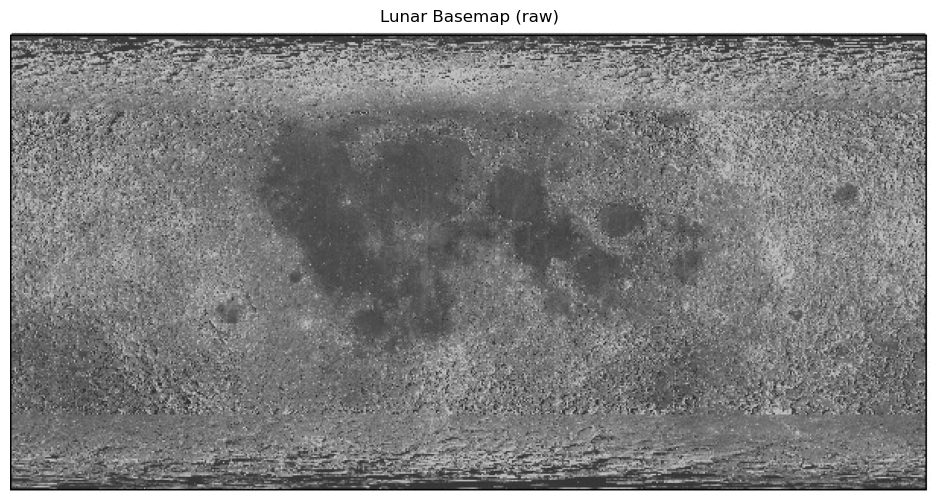

In [52]:
import matplotlib.pyplot as plt

moon_img = plt.imread("C:/Users/PhD24-2/Downloads//M3d1d2/moon map.jpg")

plt.figure(figsize=(14, 6))
plt.imshow(moon_img)
plt.title("Lunar Basemap (raw)")
plt.axis('off')
plt.show()

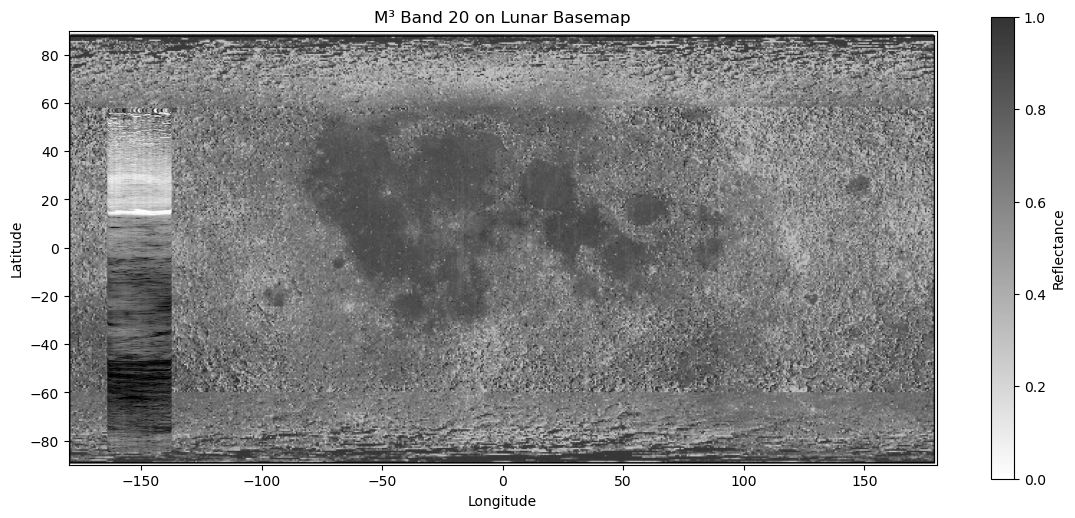

In [59]:
plt.figure(figsize=(14, 6))

plt.imshow(moon_img,
           extent=[-180, 180, -90, 90],  # map coordinates
           origin='upper')               # matches your image

plt.scatter(lon_s, lat_s,
            c=band_s,
            s=3,
            cmap='gray_r',
            alpha=0.8)

plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("M³ Band 20 on Lunar Basemap")

plt.colorbar(label="Reflectance")

plt.show()